In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. DATA COLLECTION
df = pd.read_csv('dataset.csv')

# 2. DATA PREPROCESSING & CLEANING
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['crypto_name', 'date'])

df['volume'] = df['volume'].replace(0, np.nan).ffill().fillna(1e-6)
df['marketCap'] = df['marketCap'].replace(0, np.nan).ffill().fillna(1e-6)

# 3. FEATURE ENGINEERING
df['log_return'] = df.groupby('crypto_name')['close'].transform(lambda x: np.log(x / x.shift(1)))

df['volatility_7d'] = df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())

df['liquidity_ratio'] = df['volume'] / df['marketCap']

df['sma_20'] = df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=20).mean())
df['ema_20'] = df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=20, adjust=False).mean())

df['std_20'] = df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=20).std())
df['bollinger_upper'] = df['sma_20'] + (df['std_20'] * 2)
df['bollinger_lower'] = df['sma_20'] - (df['std_20'] * 2)

def calculate_atr(group):
    high_low = group['high'] - group['low']
    high_close = np.abs(group['high'] - group['close'].shift())
    low_close = np.abs(group['low'] - group['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    return true_range.rolling(14).mean()

df['atr_14'] = df.groupby('crypto_name', group_keys=False).apply(calculate_atr)

df_cleaned = df.dropna().reset_index(drop=True)

# 4. NORMALIZATION AND SCALING
scaler = StandardScaler()
features_to_scale = ['open', 'high', 'low', 'close', 'volume', 'marketCap',
                    'log_return', 'volatility_7d', 'liquidity_ratio',
                    'sma_20', 'ema_20', 'bollinger_upper', 'bollinger_lower', 'atr_14']

df_scaled = df_cleaned.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_cleaned[features_to_scale])

# 5. SAVE PROCESSED DATA FOR PHASE 2
df_scaled.to_csv('processed_crypto_data.csv', index=False)

print("Phase 1 Completed: Data Cleaned, Features Engineered, and Scaled.")

/tmp/ipykernel_226/1383305747.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['atr_14'] = df.groupby('crypto_name', group_keys=False).apply(calculate_atr)


Phase 1 Completed: Data Cleaned, Features Engineered, and Scaled.


--- Dataset Statistics ---
         Unnamed: 0          open          high           low         close  \
count  71900.000000  7.190000e+04  7.190000e+04  7.190000e+04  7.190000e+04   
mean   36643.434687  5.059776e-17  3.162360e-17  8.222136e-17  8.854608e-17   
std    21046.956030  1.000007e+00  1.000007e+00  1.000007e+00  1.000007e+00   
min       38.000000 -1.673454e-01 -1.670500e-01 -1.671880e-01 -1.674340e-01   
25%    18449.750000 -1.673131e-01 -1.670171e-01 -1.671564e-01 -1.674016e-01   
50%    36709.500000 -1.670255e-01 -1.667229e-01 -1.668749e-01 -1.671139e-01   
75%    54874.250000 -1.622182e-01 -1.618384e-01 -1.621697e-01 -1.622956e-01   
max    72945.000000  1.265444e+01  2.966617e+01  1.282568e+01  1.264816e+01   

             volume     marketCap    log_return  volatility_7d  \
count  7.190000e+04  7.190000e+04  7.190000e+04   7.190000e+04   
mean   1.264944e-17  3.241419e-17  7.189428e-18  -9.487080e-18   
std    1.000007e+00  1.000007e+00  1.000007e+00   1.000007e+00 

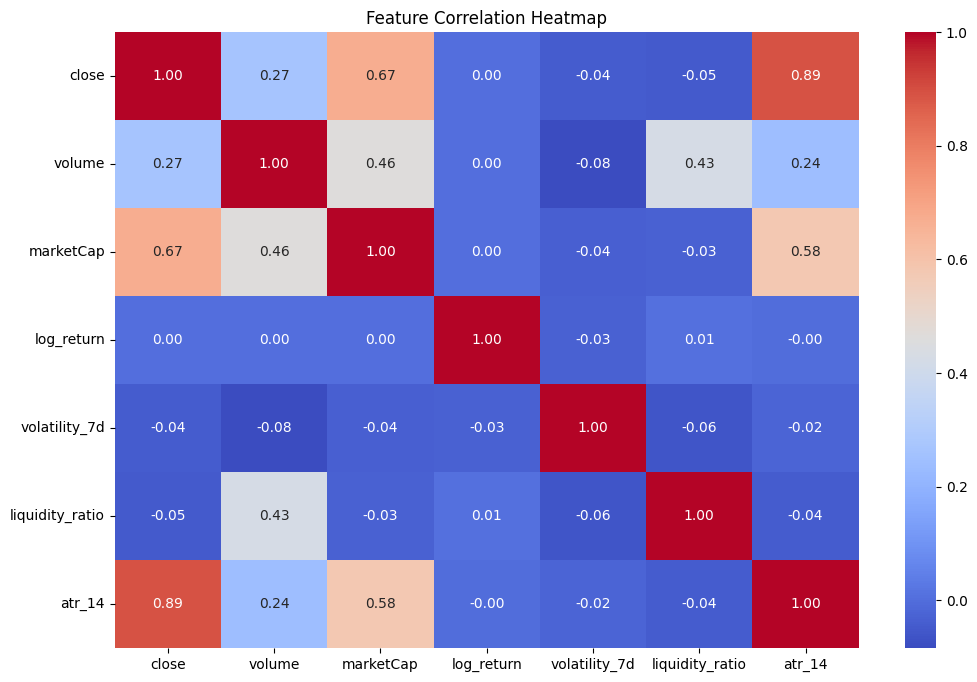

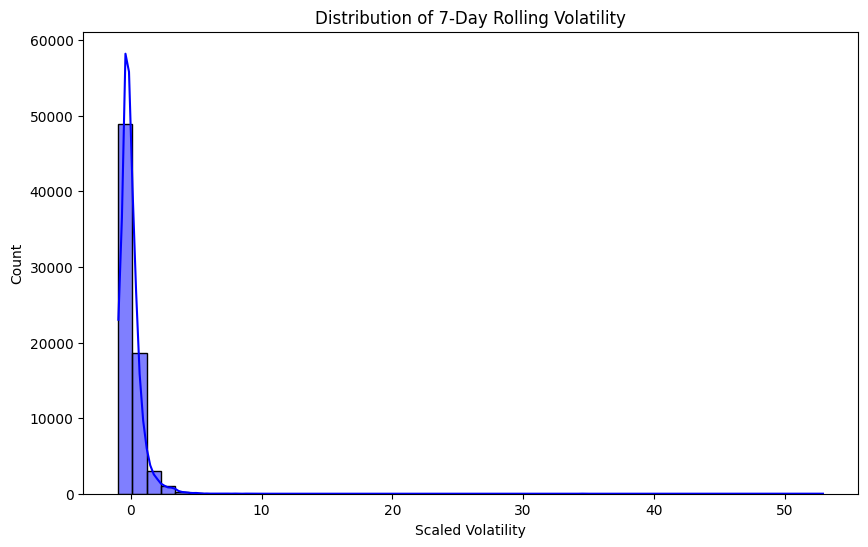


--- Top 5 Most Volatile Cryptocurrencies ---
crypto_name
Shiba Inu        2.098820
ApeCoin          1.338276
Chain            0.865910
Terra Classic    0.690056
THORChain        0.550718
Name: volatility_7d, dtype: float64


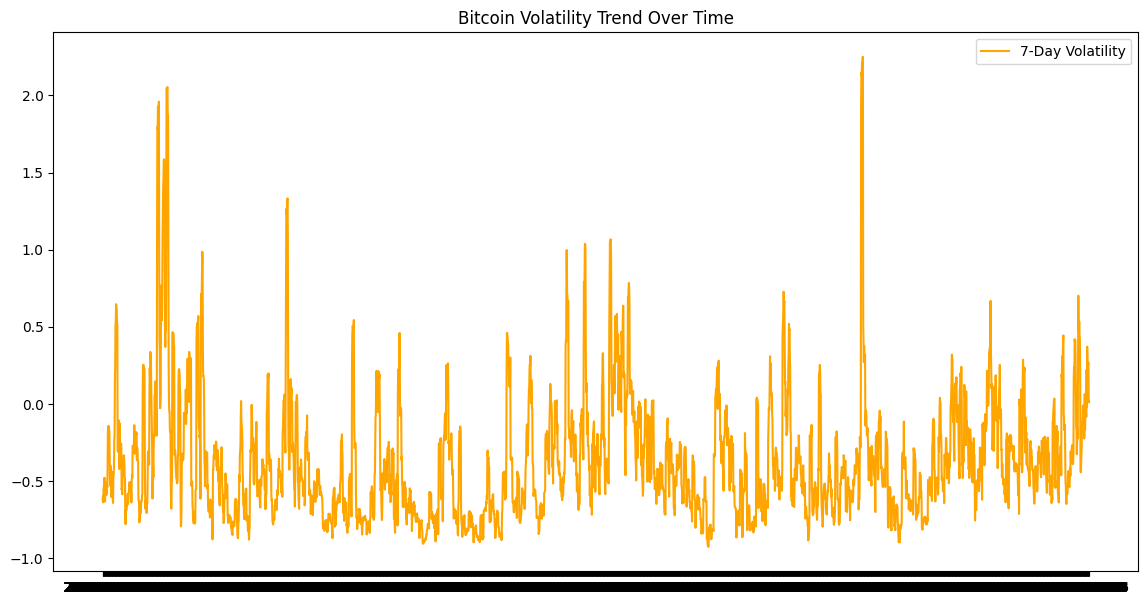

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load processed data from Phase 1
df = pd.read_csv('processed_crypto_data.csv')

# 1. Statistical Summary
print("--- Dataset Statistics ---")
print(df.describe())

# 2. Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df[['close', 'volume', 'marketCap', 'log_return', 'volatility_7d', 'liquidity_ratio', 'atr_14']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap') #
plt.show()

# 3. Volatility Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['volatility_7d'], bins=50, kde=True, color='blue')
plt.title('Distribution of 7-Day Rolling Volatility') #
plt.xlabel('Scaled Volatility')
plt.show()

# 4. Top 5 Most Volatile Cryptos (Average)
top_volatile = df.groupby('crypto_name')['volatility_7d'].mean().sort_values(ascending=False).head(5)
print("\n--- Top 5 Most Volatile Cryptocurrencies ---")
print(top_volatile)

# 5. Time Series Trend (Example: Bitcoin)
btc_data = df[df['crypto_name'] == 'Bitcoin']
plt.figure(figsize=(14, 7))
plt.plot(btc_data['date'], btc_data['volatility_7d'], label='7-Day Volatility', color='orange')
plt.title('Bitcoin Volatility Trend Over Time') #
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the processed data
df = pd.read_csv('processed_crypto_data.csv')

# 2. Features (X) aur Target (y)
features = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'log_return',
            'liquidity_ratio', 'sma_20', 'ema_20', 'bollinger_upper', 'bollinger_lower', 'atr_14']
target = 'volatility_7d'

X = df[features]
y = df[target]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Training
print("Training the Random Forest Model... Please wait.")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Performance Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

# 7. Feature Importance Check
importances = model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\n--- Key Features Driving Volatility ---")
print(feat_imp.head(5))

Training the Random Forest Model... Please wait.

--- Model Performance Results ---
Root Mean Squared Error (RMSE): 0.4076
Mean Absolute Error (MAE): 0.2387
R2 Score: 0.6815

--- Key Features Driving Volatility ---
            Feature  Importance
6        log_return    0.266608
11  bollinger_lower    0.241021
12           atr_14    0.105744
7   liquidity_ratio    0.101871
4            volume    0.061303


In [7]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameters to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Search for best parameters
rf_random = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, cv=3, random_state=42)
rf_random.fit(X_train, y_train)

# Use the best model
best_model = rf_random.best_estimator_
print(f"Best Parameters: {rf_random.best_params_}")

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}


In [25]:
import joblib

# 'model' wahi variable hai jo aapne RandomForestRegressor ke liye use kiya tha
joblib.dump(model, 'volatility_model.pkl')
print("Model successfully saved as volatility_model.pkl!")

Model successfully saved as volatility_model.pkl!


In [8]:
!pip install joblib
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.7 MB/s eta 0:00:00


In [12]:
!pip install streamlit -q
!pip install pyngrok -q

In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Page Config
st.set_page_config(page_title="Crypto Volatility Predictor", layout="wide")

# Title & Description [cite: 1, 19, 20]
st.title("Cryptocurrency Volatility Predictor")
st.write("Machine Learning based forecasting for market stability using historical data.")

# Load Data [cite: 22, 51]
try:
    df = pd.read_csv('processed_crypto_data.csv')
    model = joblib.load('volatility_model.pkl')

    # Sidebar Selection [cite: 25]
    crypto_list = df['crypto_name'].unique()
    selected_crypto = st.sidebar.selectbox("Select Cryptocurrency", crypto_list)

    # Filter & Display [cite: 33, 55]
    crypto_data = df[df['crypto_name'] == selected_crypto].sort_values('date')
    st.subheader(f"7-Day Rolling Volatility Trend: {selected_crypto}")
    st.line_chart(crypto_data.tail(30).set_index('date')['volatility_7d'])

    # Prediction [cite: 35, 48]
    if st.button("Predict Next Volatility Level"):
        features = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'log_return',
                    'liquidity_ratio', 'sma_20', 'ema_20', 'bollinger_upper', 'bollinger_lower', 'atr_14']
        latest_input = crypto_data[features].iloc[-1:].values
        prediction = model.predict(latest_input)
        st.success(f"Predicted Volatility Level: **{prediction[0]:.4f}**")

except Exception as e:
    st.error(f"Error: Ensure 'processed_crypto_data.csv' and 'volatility_model.pkl' are uploaded. {e}")

Writing app.py


In [28]:
!curl ipv4.icanhazip.com

34.171.51.154


In [30]:
!npm install -g localtunnel

!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://evil-bobcats-think.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.171.51.154:8501

  Stopping...
^C
